# Biểu diễn và các dạng tín hiệu cơ bản

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dangquanghieu/tinhieu-hethong-notebooks/blob/main/notebooks/01_bieu-dien-tin-hieu.ipynb)

Notebook minh họa cách biểu diễn tín hiệu rời rạc và liên tục, năng lượng và công suất của tín hiệu, các phép toán trên tín hiệu, cùng hàm xung đơn vị và hàm nhảy đơn vị.

**Mục tiêu**
- Phân biệt cách biểu diễn tín hiệu rời rạc $x[n]$ và tín hiệu liên tục $x(t)$ bằng công thức, bảng giá trị và đồ thị.
- Phân biệt tín hiệu năng lượng (energy signal) với tín hiệu công suất (power signal) qua tổng năng lượng và công suất trung bình.
- Quan sát phép dịch, co dãn thời gian và các phép toán trên biên độ (amplitude).
- Nhận diện tín hiệu tuần hoàn, chẵn/lẻ, hàm mũ và hình sin.
- Hiểu quan hệ giữa hàm xung đơn vị và hàm nhảy đơn vị; phân biệt $\delta[n]$ với hàm suy rộng $\delta(t)$.

**Ghi chú**: Đây là tài liệu bổ trợ cho [Bài giảng Tín hiệu và hệ thống](https://github.com/dangquanghieu/book-thht)


## Tóm tắt lý thuyết

Tín hiệu là hàm theo thời gian: tín hiệu liên tục theo thời gian (continuous-time signal) có biến $t\in\mathbb{R}$, còn tín hiệu rời rạc theo thời gian (discrete-time signal) chỉ xác định tại chỉ số nguyên $n\in\mathbb{Z}$. Tín hiệu có thể được mô tả bằng công thức, đồ thị hoặc liệt kê mẫu.

Tổng năng lượng (total energy) và công suất trung bình (average power) trên cửa sổ hữu hạn được tính như sau:

$$
E_x(T)=\int_{-T}^{T}|x(t)|^2\,dt, \qquad P_x(T)=\frac{E_x(T)}{2T}.
$$

$$
E_x[N]=\sum_{n=-N}^{N}|x[n]|^2, \qquad P_x[N]=\frac{E_x[N]}{2N+1}.
$$

Khi mở rộng cửa sổ, các đại lượng này tiến tới tổng năng lượng $E_x$ và công suất trung bình $P_x$. Tín hiệu năng lượng có $E_x<\infty$ (và $P_x=0$); tín hiệu công suất có $0<P_x<\infty$ (và $E_x=\infty$). Giá trị trên cửa sổ hữu hạn chỉ là phép tính gần đúng các giới hạn này.

Phép dịch thời gian (time shifting), phép co dãn thời gian (time scaling) và phép lấy đối xứng (time reversal) tác động lên biến độc lập. Chẳng hạn $x(t-T)$ dịch tín hiệu sang phải $T$ giây khi $T>0$, còn $x(-t)$ đảo trục thời gian. Với dãy rời rạc, độ dịch phải là số nguyên; phép co $x[2n]$ chỉ giữ các mẫu có chỉ số chẵn.

Một số dạng cơ bản gồm tín hiệu tuần hoàn (periodic signal), tín hiệu chẵn/lẻ (even/odd signals), tín hiệu hàm mũ (exponential signal) và tín hiệu hình sin (sinusoidal signal). Hàm nhảy đơn vị (unit step) được quy ước bởi $u(t)=1$ khi $t\ge0$, và tương tự $u[n]=1$ khi $n\ge0$; do đó $u(0)=1$. Hàm xung đơn vị (unit impulse) rời rạc thỏa $\delta[n]=u[n]-u[n-1]$. Với tín hiệu liên tục, hàm delta Dirac (Dirac delta function) $\delta(t)$ là hàm suy rộng (generalized function) có diện tích đơn vị, không phải hàm thông thường có chiều cao hữu hạn.

*Xem thêm: [sách Tín hiệu và hệ thống](https://github.com/dangquanghieu/book-thht), Chương 1, mục 1.1 (Định nghĩa và phân loại tín hiệu), 1.2 (Biểu diễn tín hiệu trên miền thời gian), 1.3 (Năng lượng và công suất của tín hiệu), 1.4 (Các phép toán thực hiện trên tín hiệu), 1.5 (Một số dạng tín hiệu cơ bản), các mục Hàm nhảy đơn vị và Hàm xung đơn vị.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Cấu hình phần trình bày: màu sắc, cỡ chữ, lưới và độ phân giải.
COLORS = {
    "main": "#0072B2",
    "compare": "#D55E00",
    "extra": "#009E73",
    "reference": "#CC79A7",
}

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.color": "#D9E2EA",
    "grid.alpha": 0.8,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "lines.linewidth": 1.8,
    "axes.prop_cycle": plt.cycler(color=[
        COLORS["main"], COLORS["compare"], COLORS["extra"], COLORS["reference"]
    ]),
})

In [2]:
# Các hàm dưới đây chỉ định cách trình bày từng loại đồ thị.
def stem(ax, n, x, label=None, color=None):
    """Vẽ dãy rời rạc x[n] tại các chỉ số n đã cho."""
    if color is None:
        color = COLORS["main"]

    marker, stems, baseline = ax.stem(
        n, x, linefmt="-", markerfmt="o", basefmt="k-", label=label
    )
    plt.setp(stems, color=color, linewidth=1.5)
    plt.setp(marker, color=color, markerfacecolor=color, markersize=6)
    plt.setp(baseline, linewidth=0.8)
    ax.set_xlabel("Chỉ số thời gian $n$ (mẫu)")
    return ax

def style_continuous(ax):
    """Đặt nhãn trục cho đồ thị tín hiệu liên tục."""
    ax.set_xlabel("Thời gian $t$ (s)")
    ax.set_ylabel("Biên độ")

def style_discrete(ax):
    """Đặt nhãn biên độ cho đồ thị tín hiệu rời rạc."""
    ax.set_ylabel("Biên độ")

## 1. Biểu diễn tín hiệu theo thời gian

Dãy bên trái được liệt kê tại các chỉ số từ $n=-2$ đến $n=3$; mũi tên đánh dấu mẫu tại $n=0$. Đồ thị bên phải biểu diễn một tín hiệu liên tục theo từng đoạn. Dãy rời rạc được vẽ bằng các điểm và thân thẳng đứng, còn tín hiệu liên tục bằng đường liền.

n: [-2 -1  0  1  2  3]
x[n]: [ 1.   0.5 -2.   0.   3.  -1. ]


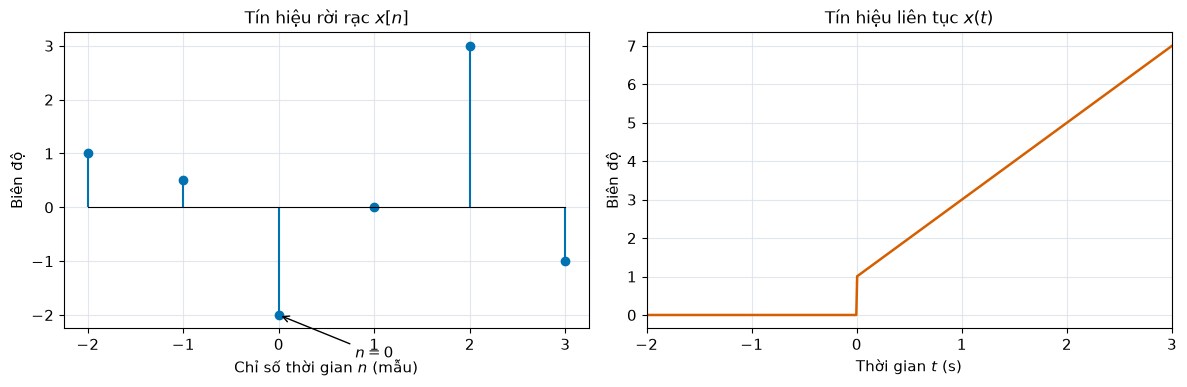

In [3]:
# Các giá trị được liệt kê theo thứ tự n = -2, -1, 0, 1, 2, 3.
n = np.arange(-2, 4)
x_n = np.array([1.0, 0.5, -2.0, 0.0, 3.0, -1.0])
print("n:", n)
print("x[n]:", x_n)

# Ví dụ liên tục từng đoạn: x(t) = 2t + 1 khi t >= 0, bằng 0 khi t < 0.
t = np.linspace(-2, 3, 600)
x_t = np.where(t >= 0, 2 * t + 1, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stem(axes[0], n, x_n)
style_discrete(axes[0])
axes[0].set_title("Tín hiệu rời rạc $x[n]$")
axes[0].set_xticks(n)
axes[0].annotate("$n=0$", xy=(0, -2), xytext=(0.8, -2.8),
                 arrowprops={"arrowstyle": "->"})

axes[1].plot(t, x_t, color=COLORS["compare"])
style_continuous(axes[1])
axes[1].set_title("Tín hiệu liên tục $x(t)$")
axes[1].set_xlim(-2, 3)
fig.tight_layout()
plt.show()

**Nhận xét.** Giá trị của dãy chỉ có ý nghĩa tại các số nguyên $n$; các đoạn thẳng đứng chỉ giúp nhìn rõ từng mẫu, không hàm ý có giá trị ở giữa các mẫu. Mảng chỉ số `n` được lưu riêng với mảng `x_n`, nên vị trí gốc thời gian không bị ngầm giả định.

## 2. Tổng năng lượng và công suất trung bình

Ta so sánh một tín hiệu suy giảm có năng lượng hữu hạn với một tín hiệu tuần hoàn có công suất trung bình hữu hạn. Với thời gian liên tục, cửa sổ quan sát là $[-T,T]$; với thời gian rời rạc, cửa sổ gồm các mẫu $-N\le n\le N$. Các đại lượng vẽ được đều tính trên cửa sổ hữu hạn, còn đường tiệm cận cho biết giới hạn khi cửa sổ mở rộng.

Tín hiệu liên tục suy giảm được chọn là $x(t)=e^{-a|t|}$ với $a>0$; tín hiệu tuần hoàn là $x(t)=5\cos(2\pi\cdot50t-\pi/3)$. Để minh họa tương tự trong rời rạc, dùng $x[n]=\rho^{|n|}$ với $0<\rho<1$ và $x[n]=2\cos(\pi n/4-\pi/3)$.

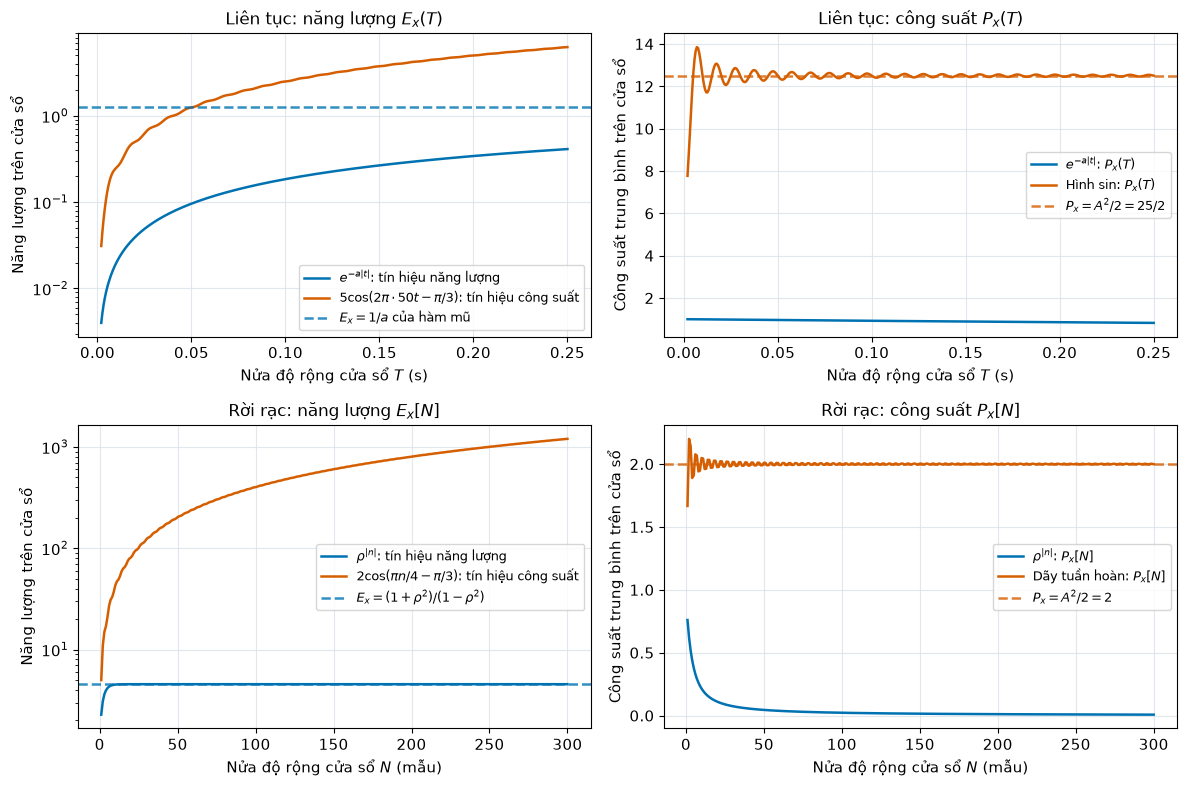

Giới hạn năng lượng liên tục của hàm mũ: 1.2500
Công suất trung bình liên tục của hình sin: 12.5000
Giới hạn năng lượng rời rạc của hàm mũ: 4.5556
Công suất trung bình rời rạc của dãy cosin: 2.0000


In [4]:
# --- Tính các tín hiệu và đại lượng cần vẽ ---
# Năng lượng và công suất trên các cửa sổ đối xứng quanh gốc thời gian.
T = np.linspace(0.002, 0.25, 400)
a = 0.8
energy_exp_t = (1 - np.exp(-2 * a * T)) / a
power_exp_t = energy_exp_t / (2 * T)

amplitude_t = 5.0
omega_t = 2 * np.pi * 50
phase_t = -np.pi / 3
energy_cos_t = amplitude_t ** 2 * (
    T + (np.sin(2 * omega_t * T + 2 * phase_t)
         - np.sin(-2 * omega_t * T + 2 * phase_t)) / (4 * omega_t)
)
power_cos_t = energy_cos_t / (2 * T)

# Tính trực tiếp các tổng rời rạc trên từng cửa sổ [-N, N].
N = np.arange(1, 301)
n_all = np.arange(-N[-1], N[-1] + 1)
rho = 0.8
x_exp_n = rho ** np.abs(n_all)
amplitude_n = 2.0
omega_n = np.pi / 4
phase_n = -np.pi / 3
x_cos_n = amplitude_n * np.cos(omega_n * n_all + phase_n)
center = N[-1]

# Cách 1: vòng for tường minh, mỗi lần lặp tính tổng trên một cửa sổ [-w, w].
energy_exp_n = np.zeros(len(N))
energy_cos_n = np.zeros(len(N))
for i, window in enumerate(N):
    start = center - window
    stop = center + window + 1
    energy_exp_n[i] = np.sum(np.abs(x_exp_n[start:stop]) ** 2)
    energy_cos_n[i] = np.sum(np.abs(x_cos_n[start:stop]) ** 2)

# Cách 2: list comprehension, cho cùng kết quả với vòng for ở trên.
energy_exp_n_lc = [np.sum(np.abs(x_exp_n[center - w:center + w + 1]) ** 2) for w in N]
assert np.allclose(energy_exp_n, energy_exp_n_lc)

power_exp_n = energy_exp_n / (2 * N + 1)
power_cos_n = energy_cos_n / (2 * N + 1)

# --- Vẽ kết quả; màu, font và lưới đã cấu hình ở cell khởi tạo ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(T, energy_exp_t, label="$e^{-a|t|}$: tín hiệu năng lượng")
axes[0, 0].plot(T, energy_cos_t, label="$5\\cos(2\\pi\\cdot50t-\\pi/3)$: tín hiệu công suất")
axes[0, 0].axhline(1 / a, color=COLORS["main"], linestyle="--", alpha=0.8,
                   label="$E_x=1/a$ của hàm mũ")
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Nửa độ rộng cửa sổ $T$ (s)")
axes[0, 0].set_ylabel("Năng lượng trên cửa sổ")
axes[0, 0].set_title("Liên tục: năng lượng $E_x(T)$")
axes[0, 0].legend()

axes[0, 1].plot(T, power_exp_t, label="$e^{-a|t|}$: $P_x(T)$")
axes[0, 1].plot(T, power_cos_t, label="Hình sin: $P_x(T)$")
axes[0, 1].axhline(amplitude_t ** 2 / 2, color=COLORS["compare"], linestyle="--", alpha=0.8,
                   label="$P_x=A^2/2=25/2$")
axes[0, 1].set_xlabel("Nửa độ rộng cửa sổ $T$ (s)")
axes[0, 1].set_ylabel("Công suất trung bình trên cửa sổ")
axes[0, 1].set_title("Liên tục: công suất $P_x(T)$")
axes[0, 1].legend()

axes[1, 0].plot(N, energy_exp_n, label="$\\rho^{|n|}$: tín hiệu năng lượng")
axes[1, 0].plot(N, energy_cos_n, label="$2\\cos(\\pi n/4-\\pi/3)$: tín hiệu công suất")
axes[1, 0].axhline((1 + rho ** 2) / (1 - rho ** 2), color=COLORS["main"],
                   linestyle="--", alpha=0.8, label="$E_x=(1+\\rho^2)/(1-\\rho^2)$")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("Nửa độ rộng cửa sổ $N$ (mẫu)")
axes[1, 0].set_ylabel("Năng lượng trên cửa sổ")
axes[1, 0].set_title("Rời rạc: năng lượng $E_x[N]$")
axes[1, 0].legend()

axes[1, 1].plot(N, power_exp_n, label="$\\rho^{|n|}$: $P_x[N]$")
axes[1, 1].plot(N, power_cos_n, label="Dãy tuần hoàn: $P_x[N]$")
axes[1, 1].axhline(amplitude_n ** 2 / 2, color=COLORS["compare"], linestyle="--", alpha=0.8,
                   label="$P_x=A^2/2=2$")
axes[1, 1].set_xlabel("Nửa độ rộng cửa sổ $N$ (mẫu)")
axes[1, 1].set_ylabel("Công suất trung bình trên cửa sổ")
axes[1, 1].set_title("Rời rạc: công suất $P_x[N]$")
axes[1, 1].legend()

fig.tight_layout()
plt.show()

print(f"Giới hạn năng lượng liên tục của hàm mũ: {1 / a:.4f}")
print(f"Công suất trung bình liên tục của hình sin: {amplitude_t ** 2 / 2:.4f}")
print(f"Giới hạn năng lượng rời rạc của hàm mũ: {(1 + rho ** 2) / (1 - rho ** 2):.4f}")
print(f"Công suất trung bình rời rạc của dãy cosin: {amplitude_n ** 2 / 2:.4f}")

**Nhận xét.** Với các hàm mũ suy giảm, năng lượng trên cửa sổ tiến tới một giá trị hữu hạn, còn công suất trung bình tiến về 0: đây là tín hiệu năng lượng. Với các tín hiệu tuần hoàn khác không, năng lượng trên cửa sổ tăng không giới hạn, còn công suất trung bình tiến tới giá trị dương hữu hạn: đây là tín hiệu công suất. Đường tiệm cận và giới hạn đã nêu là kết quả lý thuyết; các đường cong chỉ tính trên những cửa sổ hữu hạn được vẽ.

## 3. Phép toán trên biến thời gian

Xét một xung chữ nhật liên tục (rectangular pulse) có giá trị 1 trên $2\le t\le4$, và một dãy có các mẫu 1, 2, 3, 4 tại $n=0,1,2,3$, bằng 0 ở nơi khác. Các đồ thị so sánh tín hiệu gốc với tín hiệu dịch, co thời gian và co kết hợp dịch. Ở dạng rời rạc, $x[2n]$ và $x[2n+1]$ lần lượt lấy các mẫu chẵn và lẻ của dãy gốc.

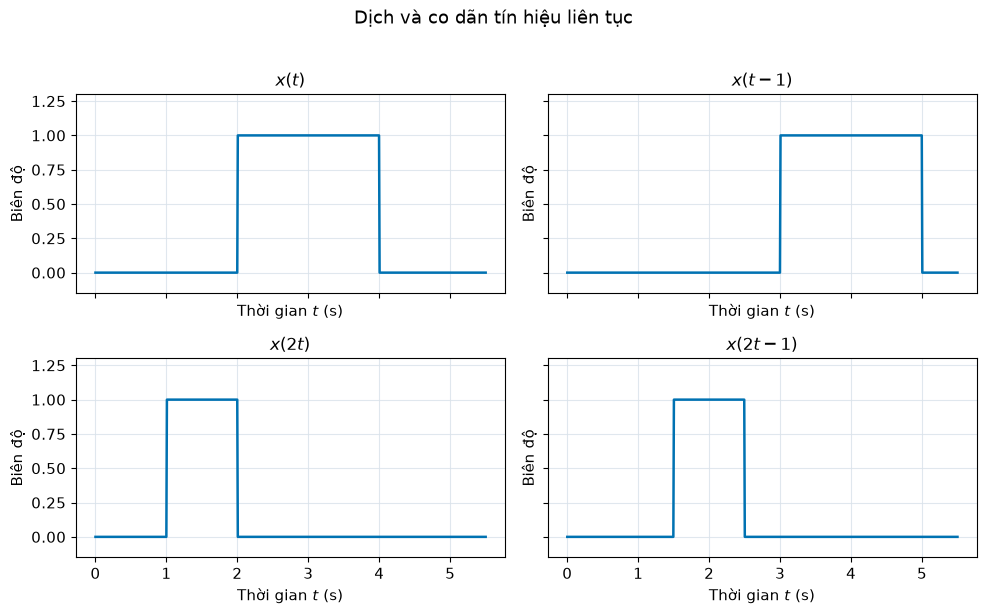

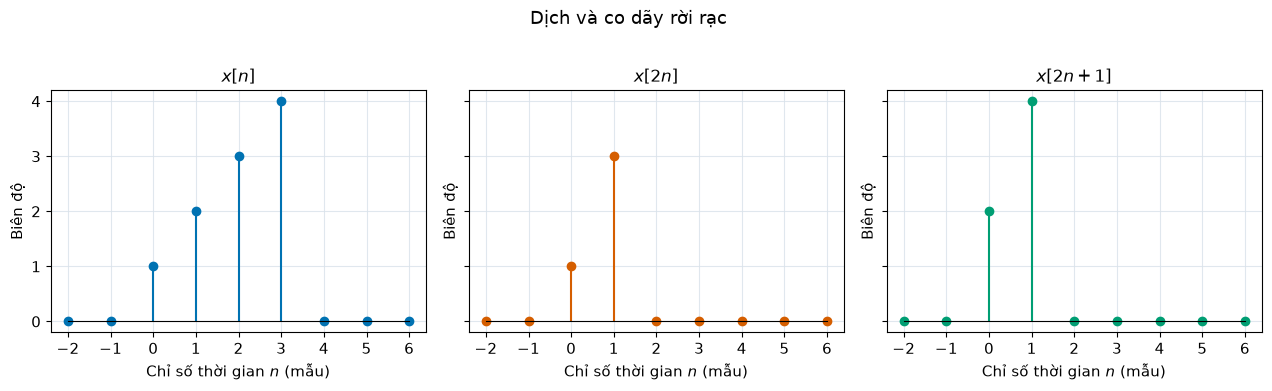

In [5]:
# Tín hiệu liên tục và các phép toán theo đúng đối số của hàm.
t = np.linspace(0, 5.5, 700)
x_cont = lambda q: ((q >= 2) & (q <= 4)).astype(float)
cont_cases = [
    (x_cont(t), "$x(t)$"),
    (x_cont(t - 1), "$x(t-1)$"),
    (x_cont(2 * t), "$x(2t)$"),
    (x_cont(2 * t - 1), "$x(2t-1)$"),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
for ax, (values, title) in zip(axes.flat, cont_cases):
    ax.plot(t, values)
    style_continuous(ax)
    ax.set_title(title)
    ax.set_ylim(-0.15, 1.3)
fig.suptitle("Dịch và co dãn tín hiệu liên tục", y=1.02)
fig.tight_layout()
plt.show()

# Dãy gốc có giá trị x[n] = n + 1 tại n = 0, 1, 2, 3; bằng 0 ở nơi khác.
n = np.arange(-2, 7)
def x_seq(q):
    return np.where((q >= 0) & (q <= 3), q + 1, 0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, values, title, color in zip(
    axes,
    [x_seq(n), x_seq(2 * n), x_seq(2 * n + 1)],
    ["$x[n]$", "$x[2n]$", "$x[2n+1]$"],
    [COLORS["main"], COLORS["compare"], COLORS["extra"]],
):
    stem(ax, n, values, color=color)
    style_discrete(ax)
    ax.set_title(title)
    ax.set_xticks(n)
fig.suptitle("Dịch và co dãy rời rạc", y=1.02)
fig.tight_layout()
plt.show()

**Nhận xét.** $x(t-1)$ dịch sang phải 1 s; $x(2t)$ co độ rộng còn một nửa. Trong dãy rời rạc, $x[2n]$ bỏ qua các mẫu lẻ của dãy gốc, còn $x[2n+1]$ lấy các mẫu lẻ. Chỉ số đầu vào của $x[\cdot]$ vẫn phải được tính tường minh tại mỗi $n$.

### Phép toán trên biên độ

Phép nhân với hằng số, phép cộng và phép nhân hai tín hiệu được thực hiện tại cùng một thời điểm. Đồ thị dưới đây dùng hai tín hiệu liên tục để minh họa ba phép toán; nguyên tắc tương tự áp dụng cho dãy rời rạc.

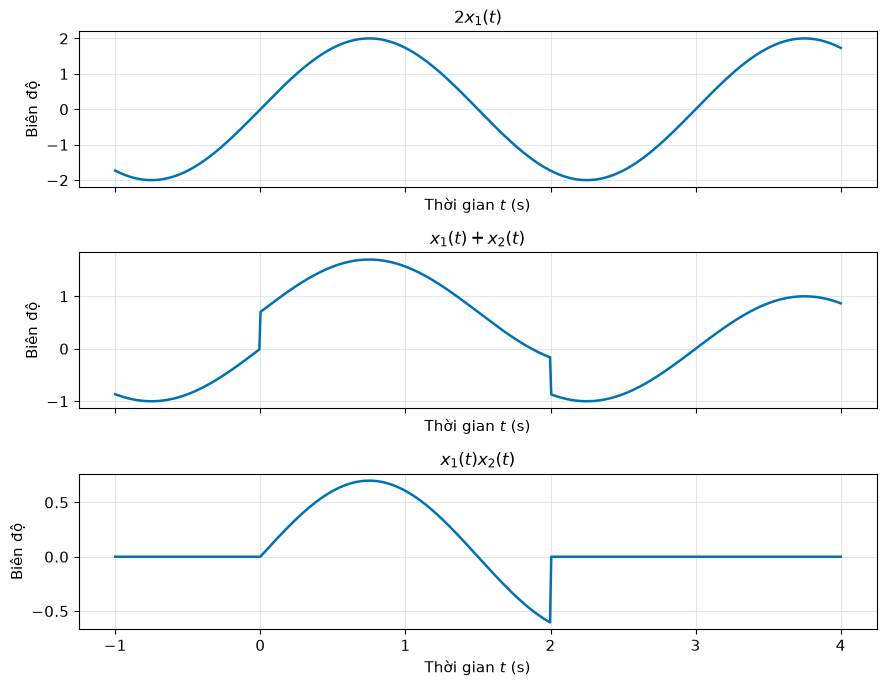

In [6]:
# --- Tạo hai tín hiệu để thực hiện phép toán trên biên độ ---
t = np.linspace(-1, 4, 600)
x1 = np.sin(2 * np.pi * t / 3)
x2 = np.zeros_like(t)
x2[(t >= 0) & (t < 2)] = 0.7

# Tính riêng kết quả của từng phép toán.
x_scaled = 2 * x1
x_sum = x1 + x2
x_product = x1 * x2

# --- Vẽ các kết quả ---
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t, x_scaled)
axes[0].set_title("$2x_1(t)$")
axes[1].plot(t, x_sum)
axes[1].set_title("$x_1(t)+x_2(t)$")
axes[2].plot(t, x_product)
axes[2].set_title("$x_1(t)x_2(t)$")
for ax in axes:
    style_continuous(ax)
fig.tight_layout()
plt.show()

**Nhận xét.** Nhân với hằng số làm thay đổi biên độ; cộng và nhân hai tín hiệu được tính điểm-theo-điểm tại cùng $t$. Phép toán trên giá trị không làm dịch trục thời gian.

## 4. Một số dạng tín hiệu cơ bản

Các đồ thị sau minh họa tín hiệu tuần hoàn, phép tách một tín hiệu thành thành phần chẵn và lẻ, hàm mũ thực và tín hiệu hình sin. Ví dụ chẵn lẻ dùng $x(t)=2+\sin(t)$ để hai thành phần hiện rõ, ít chồng lấp. Với hình sin liên tục, tần số góc (angular frequency) $\Omega_0$ được tính bằng rad/s; với hình sin rời rạc, $\omega_0$ tính bằng rad/mẫu.

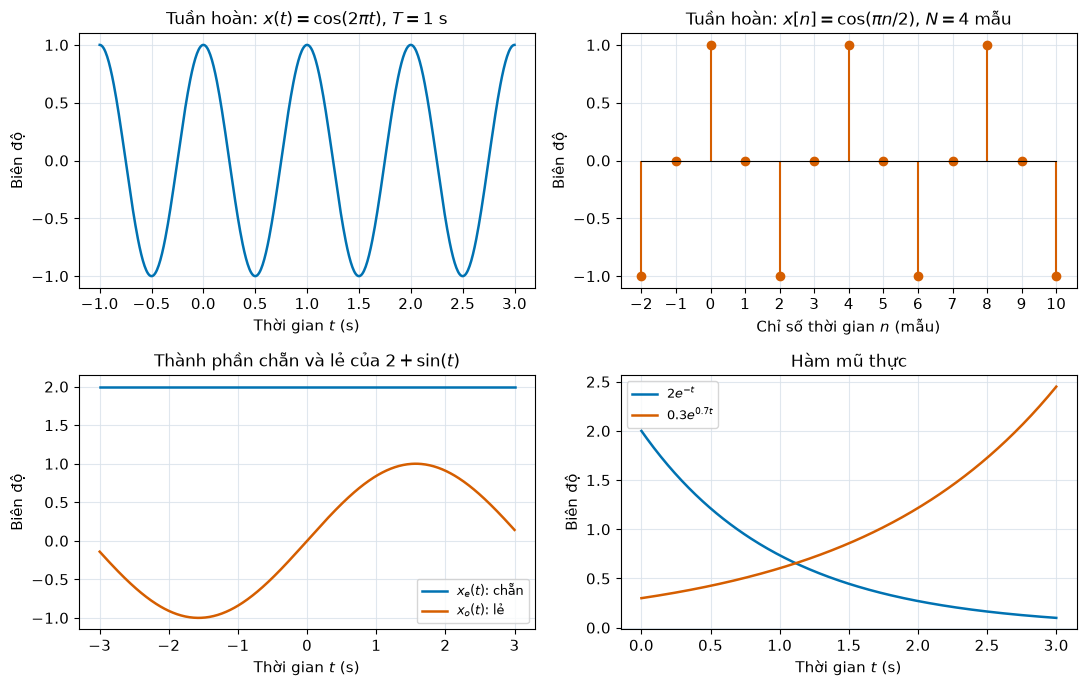

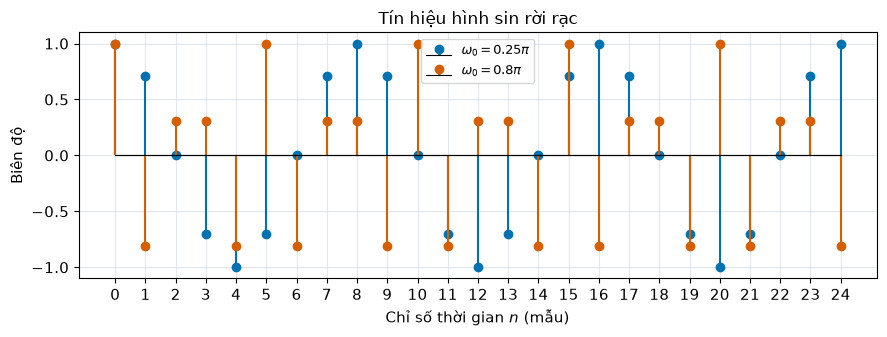

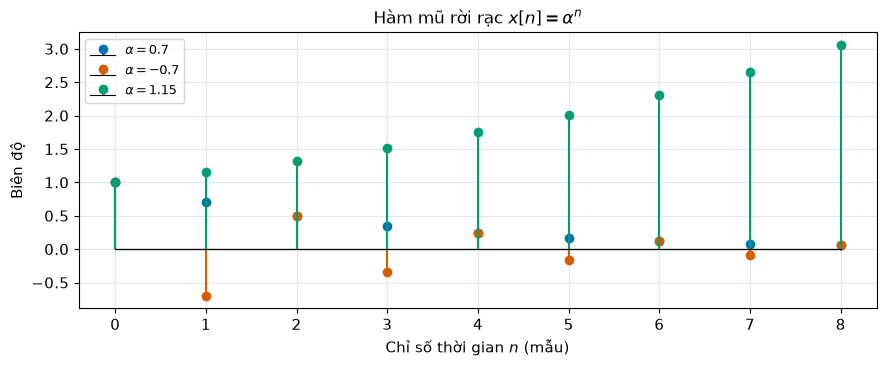

In [7]:
# --- Tín hiệu tuần hoàn ---
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Tín hiệu tuần hoàn liên tục và dãy tuần hoàn.
t = np.linspace(-1, 3, 500)
axes[0, 0].plot(t, np.cos(2 * np.pi * t))
style_continuous(axes[0, 0])
axes[0, 0].set_title("Tuần hoàn: $x(t)=\\cos(2\\pi t)$, $T=1$ s")
n = np.arange(-2, 11)
stem(axes[0, 1], n, np.cos(np.pi * n / 2), color=COLORS["compare"])
style_discrete(axes[0, 1])
axes[0, 1].set_title("Tuần hoàn: $x[n]=\\cos(\\pi n/2)$, $N=4$ mẫu")
axes[0, 1].set_xticks(n)

# --- Tách tín hiệu thành thành phần chẵn và lẻ ---
t = np.linspace(-3, 3, 500)
x = 2 + np.sin(t)
x_reflected = 2 + np.sin(-t)
x_even = (x + x_reflected) / 2
x_odd = (x - x_reflected) / 2
assert np.allclose(x, x_even + x_odd)
axes[1, 0].plot(t, x_even, label="$x_e(t)$: chẵn")
axes[1, 0].plot(t, x_odd, label="$x_o(t)$: lẻ")
style_continuous(axes[1, 0])
axes[1, 0].set_title("Thành phần chẵn và lẻ của $2+\\sin(t)$")
axes[1, 0].legend()

# --- So sánh hai hàm mũ trên một khoảng hữu hạn ---
t = np.linspace(0, 3, 300)
axes[1, 1].plot(t, 2 * np.exp(-t), label="$2e^{-t}$")
axes[1, 1].plot(t, 0.3 * np.exp(0.7 * t), label="$0.3e^{0.7t}$")
style_continuous(axes[1, 1])
axes[1, 1].set_title("Hàm mũ thực")
axes[1, 1].legend()
fig.tight_layout()
plt.show()

# --- Tần số góc khác nhau cho thấy tốc độ biến thiên khác nhau ---
n = np.arange(0, 25)
fig, ax = plt.subplots(figsize=(9, 3.5))
stem(ax, n, np.cos(0.25 * np.pi * n), label="$\\omega_0=0.25\\pi$", color=COLORS["main"])
stem(ax, n, np.cos(0.8 * np.pi * n), label="$\\omega_0=0.8\\pi$", color=COLORS["compare"])
style_discrete(ax)
ax.set_title("Tín hiệu hình sin rời rạc")
ax.set_xticks(n)
ax.legend()
fig.tight_layout()
plt.show()

# --- Hàm mũ rời rạc với các cơ số khác nhau ---
n = np.arange(0, 9)
fig, ax = plt.subplots(figsize=(9, 3.8))
alphas = [0.7, -0.7, 1.15]
colors = [COLORS["main"], COLORS["compare"], COLORS["extra"]]
for alpha, color in zip(alphas, colors):
    stem(ax, n, alpha ** n, label=f"$\\alpha={alpha}$", color=color)
style_discrete(ax)
ax.set_title("Hàm mũ rời rạc $x[n]=\\alpha^n$")
ax.set_xticks(n)
ax.legend()
fig.tight_layout()
plt.show()

**Nhận xét.** Tín hiệu tuần hoàn lặp lại sau một chu kỳ cơ bản. Với $x(t)=2+\sin(t)$, thành phần chẵn là hằng số $x_e(t)=2$, còn thành phần lẻ là $x_o(t)=\sin(t)$; chúng không chồng lên nhau trong đồ thị. Tổng hai thành phần khôi phục tín hiệu ban đầu. Hàm mũ có thể tăng hoặc giảm; trong rời rạc, cơ số âm còn làm dấu của mẫu đổi luân phiên. Với dãy hình sin, tần số rời rạc chỉ phân biệt theo chu kỳ $2\pi$; một dãy sin chỉ tuần hoàn khi $\omega_0/(2\pi)$ là số hữu tỷ.

## 5. Hàm nhảy đơn vị và hàm xung đơn vị

Hàm nhảy đơn vị $u(t)$, $u[n]$ bằng 1 từ gốc thời gian trở đi, với quy ước $u(0)=1$. Hàm xung đơn vị rời rạc chỉ khác không tại $n=0$, đồng thời $\delta[n]=u[n]-u[n-1]$. Trong dãy hữu hạn dưới đây, ta kiểm chứng biểu diễn mỗi mẫu bằng một xung đã dịch và được nhân với giá trị mẫu.

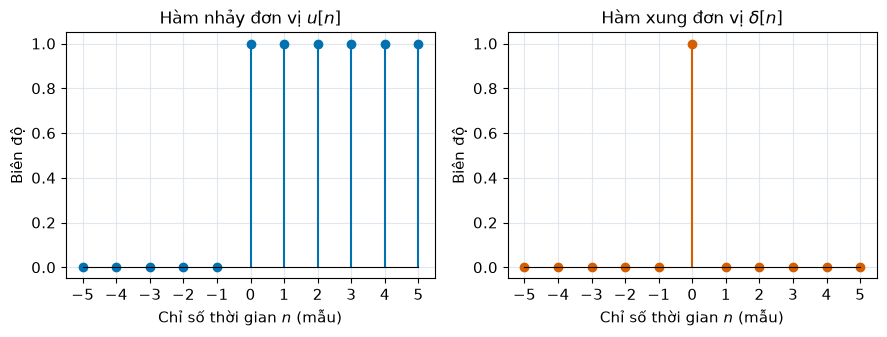

Biểu diễn bằng các xung dịch khớp với dãy ban đầu: True


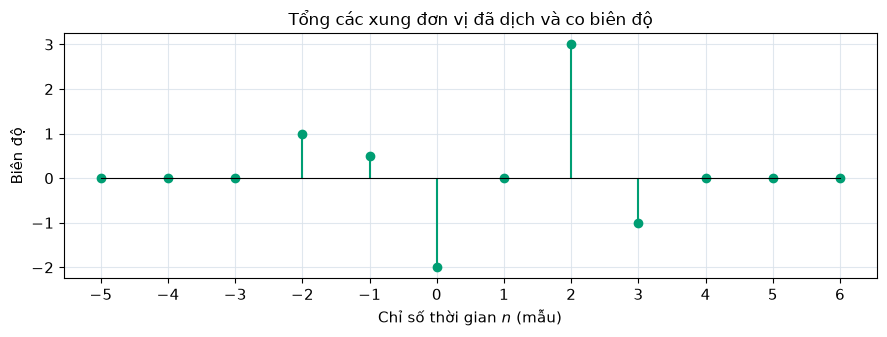

In [8]:
# --- Tạo các dãy hàm nhảy và hàm xung ---
n = np.arange(-5, 6)
u_n = (n >= 0).astype(float)
delta_n = (n == 0).astype(float)
u_prev = ((n - 1) >= 0).astype(float)
assert np.array_equal(delta_n, u_n - u_prev)

# --- Vẽ hai dãy và so sánh quan hệ giữa chúng ---
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
stem(axes[0], n, u_n)
style_discrete(axes[0])
axes[0].set_title("Hàm nhảy đơn vị $u[n]$")
axes[0].set_xticks(n)
stem(axes[1], n, delta_n, color=COLORS["compare"])
style_discrete(axes[1])
axes[1].set_title("Hàm xung đơn vị $\\delta[n]$")
axes[1].set_xticks(n)
fig.tight_layout()
plt.show()

# --- Biểu diễn dãy bằng tổng các xung đã dịch ---
n_x = np.arange(-2, 4)
x_values = np.array([1.0, 0.5, -2.0, 0.0, 3.0, -1.0])
n_out = np.arange(-5, 7)
x_from_impulses = np.zeros_like(n_out, dtype=float)
for k, value in zip(n_x, x_values):
    # Mỗi vòng lặp đặt một mẫu vào đúng chỉ số k.
    x_from_impulses += value * (n_out == k)
x_direct = np.zeros_like(n_out, dtype=float)
for k, value in zip(n_x, x_values):
    x_direct[n_out == k] = value
assert np.allclose(x_from_impulses, x_direct)
print("Biểu diễn bằng các xung dịch khớp với dãy ban đầu:",
      np.allclose(x_from_impulses, x_direct))

fig, ax = plt.subplots(figsize=(9, 3.5))
stem(ax, n_out, x_from_impulses, color=COLORS["extra"])
style_discrete(ax)
ax.set_title("Tổng các xung đơn vị đã dịch và co biên độ")
ax.set_xticks(n_out)
fig.tight_layout()
plt.show()

Với thời gian liên tục, $u(t)$ vẫn được vẽ như một hàm bậc thang. Không thể vẽ $\delta(t)$ như một đường có chiều cao hữu hạn: hình bên phải dùng mũi tên để biểu thị xung có diện tích bằng 1. Các hình chữ nhật bên trái có cùng diện tích đơn vị và độ rộng giảm dần, minh họa giới hạn khái niệm dẫn đến hàm delta Dirac.

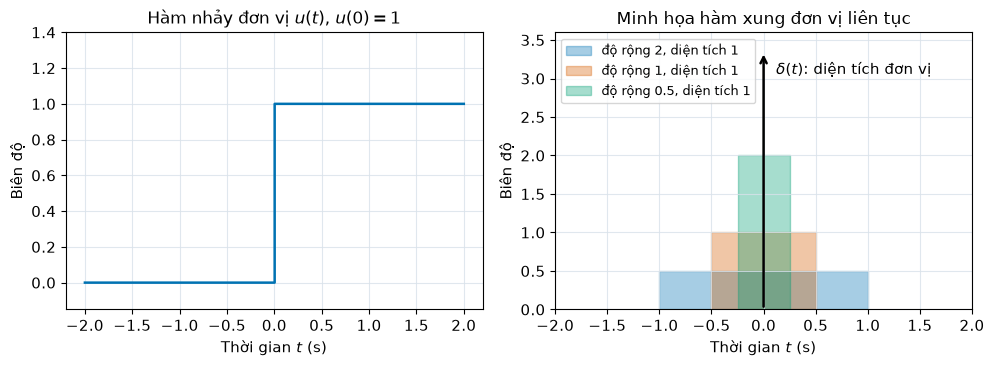

In [9]:
# --- Tạo hàm nhảy liên tục ---
t = np.linspace(-2, 2, 600)
u_t = (t >= 0).astype(float)
# --- Vẽ hàm nhảy và minh họa các xung có diện tích đơn vị ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].plot(t, u_t, drawstyle="steps-post")
style_continuous(axes[0])
axes[0].set_title("Hàm nhảy đơn vị $u(t)$, $u(0)=1$")
axes[0].set_ylim(-0.15, 1.4)

# Các xung chữ nhật đều có diện tích 1; chiều cao không phải giá trị của delta(t).
widths = [2.0, 1.0, 0.5]
colors = [COLORS["main"], COLORS["compare"], COLORS["extra"]]
for width, color in zip(widths, colors):
    axes[1].bar(0, 1 / width, width=width, color=color, alpha=0.35,
                edgecolor=color, label=f"độ rộng {width:g}, diện tích 1")
axes[1].annotate("", xy=(0, 3.35), xytext=(0, 0),
                 arrowprops={"arrowstyle": "->", "linewidth": 1.8})
axes[1].text(0.12, 3.05, "$\\delta(t)$: diện tích đơn vị", ha="left")
style_continuous(axes[1])
axes[1].set_title("Minh họa hàm xung đơn vị liên tục")
axes[1].set_xlim(-2, 2)
axes[1].set_ylim(0, 3.6)
axes[1].legend()
fig.tight_layout()
plt.show()

**Nhận xét.** Trong rời rạc, $\delta[n]$ là dãy có giá trị 1 tại gốc và 0 ở các chỉ số khác; lấy hiệu hai hàm nhảy liên tiếp tạo ra đúng dãy này. Mọi dãy hữu hạn có thể viết thành tổng các xung đơn vị dịch, với hệ số bằng giá trị từng mẫu. Trong liên tục, $\delta(t)$ được xác định qua tích phân và tính chất lấy mẫu; không đồng nhất nó với bất kỳ hình chữ nhật hữu hạn nào.

## Câu hỏi suy ngẫm

1. Vì sao khi vẽ tín hiệu rời rạc cần cho biết rõ mảng chỉ số đi kèm mảng giá trị?
2. Tín hiệu $x(t-2)$ khác $x(2t)$ như thế nào về vị trí và độ rộng?
3. Vì sao phép co $x[2n]$ làm mất một phần mẫu của dãy rời rạc?
4. Một dãy hình sin rời rạc cần điều kiện gì để tuần hoàn?
5. Vì sao không thể biểu diễn $\delta(t)$ bằng một xung có chiều cao hữu hạn và diện tích bằng 1?